# Detección de uso de cascos de seguridad en entornos laborales
### Clasificación binaria con CNN

## 1. Introducción: Problema y motivación

Según la Organización Internacional del Trabajo (OIT), al menos 60.000 trabajadores mueren cada año en accidentes en obras de construcción en todo el mundo. En Uruguay, según datos de la Inspección General del Trabajo y de la Seguridad Social (IGTSS), se registran aproximadamente 40.000 accidentes laborales por año, de los cuales 6.000 corresponden al sector de la construcción. En 2025, el 33% de los fallecimientos laborales ocurrió en este sector, siendo las caídas desde altura la principal causa de muerte. Un número significativo de estos accidentes se vincula al no uso del Equipo de Protección Personal (EPP) requerido, como cascos de seguridad.

Este proyecto busca desarrollar un sistema basado en deep learning capaz de clasificar automáticamente si los trabajadores en obras de construcción están usando cascos de seguridad. Se utiliza una **Red Neuronal Convolucional (CNN)** para clasificación binaria: **con casco** vs **sin casco**. Dicho sistema podría integrarse con cámaras de vigilancia existentes para proporcionar monitoreo y alertas en tiempo real.

## 2. Solución propuesta

La solución consiste en una CNN de clasificación binaria que recibe como entrada recortes de personas/cabezas extraídos de imágenes de obras de construcción y predice si la persona lleva casco o no.

**Pipeline completo:**
1. Se extraen las bounding boxes anotadas en formato XML (Pascal VOC) del dataset
2. Se recorta cada región de interés de la imagen original
3. Se agrupan las 6 clases originales en 2 clases binarias: *con casco* (helmet, head with helmet, person with helmet) y *sin casco* (head, person without helmet, face)
4. Se redimensionan los recortes a 64x64 píxeles y se normalizan
5. Se entrena una CNN con capas convolucionales, BatchNormalization, MaxPooling y Dropout
6. Se evalúa con métricas de clasificación (accuracy, precision, recall, F1, AUC-ROC)

## 3. Descripción de los datos

Se utiliza el dataset **SHEL5K** (Safety HELmet dataset with 5K images), un benchmark público para detección de cascos de seguridad disponible en Kaggle. El dataset consta de 5.000 imágenes que contienen 75.570 instancias anotadas en 6 clases:
- **helmet**: casco solo
- **head**: cabeza sin casco
- **head with helmet**: cabeza con casco
- **person with helmet**: persona con casco
- **person without helmet**: persona sin casco
- **face**: rostro visible (sin casco)

Para la clasificación binaria, las clases se agrupan en:
- **Con casco (1):** helmet, head with helmet, person with helmet
- **Sin casco (0):** head, person without helmet, face

Fuente: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection

## Imports

In [ ]:
!pip install opencv-python -q
!pip install tensorflow -q

In [ ]:
import kagglehub
import os
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras import layers, Model

# Verificar GPU
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Descarga del dataset

In [ ]:
path = kagglehub.dataset_download("andrewmvd/hard-hat-detection")
print("Path to dataset files:", path)

100%|██████████| 1.22G/1.22G [00:14<00:00, 91.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1


In [ ]:
for root, dirs, files in os.walk(path):
    print(root)
    for name in files[:3]:
        print("   ", name)

/root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1
/root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1/images
    hard_hat_workers709.png
    hard_hat_workers183.png
    hard_hat_workers2539.png
/root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1/annotations
    hard_hat_workers2138.xml
    hard_hat_workers4240.xml
    hard_hat_workers3397.xml


In [ ]:
images_dir = os.path.join(path, "images")
annotations_dir = os.path.join(path, "annotations")

print(len(os.listdir(images_dir)), "images")
print(len(os.listdir(annotations_dir)), "annotations")

5000 images
5000 annotations


## Exploración del dataset

Inspeccionamos la estructura de las anotaciones XML y visualizamos una imagen con sus bounding boxes.

In [ ]:
# Inspeccionar una anotación XML para entender la estructura
sample_xml = os.listdir(annotations_dir)[0]
tree = ET.parse(os.path.join(annotations_dir, sample_xml))
root = tree.getroot()

print("Estructura del XML:")
print(f"  Filename: {root.find('filename').text}")
print(f"  Size: {root.find('size/width').text}x{root.find('size/height').text}")
print(f"  Objetos encontrados: {len(root.findall('object'))}")
for obj in root.findall('object'):
    name = obj.find('name').text
    bndbox = obj.find('bndbox')
    print(f"    Clase: {name}, BBox: ({bndbox.find('xmin').text}, {bndbox.find('ymin').text}) -> ({bndbox.find('xmax').text}, {bndbox.find('ymax').text})")

Estructura del XML:
  Filename: hard_hat_workers2138.png
  Size: 416x415
  Objetos encontrados: 10
    Clase: helmet, BBox: (97, 158) -> (130, 192)
    Clase: helmet, BBox: (201, 169) -> (215, 189)
    Clase: helmet, BBox: (188, 168) -> (202, 187)
    Clase: helmet, BBox: (226, 171) -> (242, 190)
    Clase: helmet, BBox: (243, 166) -> (257, 184)
    Clase: helmet, BBox: (262, 165) -> (280, 189)
    Clase: helmet, BBox: (362, 145) -> (401, 184)
    Clase: helmet, BBox: (278, 141) -> (316, 184)
    Clase: helmet, BBox: (308, 162) -> (323, 184)
    Clase: helmet, BBox: (348, 164) -> (364, 185)


In [ ]:
# Contar todas las clases en el dataset para entender la distribución
class_counts = {}
for xml_file in os.listdir(annotations_dir):
    tree = ET.parse(os.path.join(annotations_dir, xml_file))
    for obj in tree.getroot().findall('object'):
        name = obj.find('name').text
        class_counts[name] = class_counts.get(name, 0) + 1

print("Distribución de clases en el dataset:")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls}: {count}")
print(f"\nTotal de instancias: {sum(class_counts.values())}")

Distribución de clases en el dataset:
  helmet: 18966
  head: 5785
  person: 751

Total de instancias: 25502


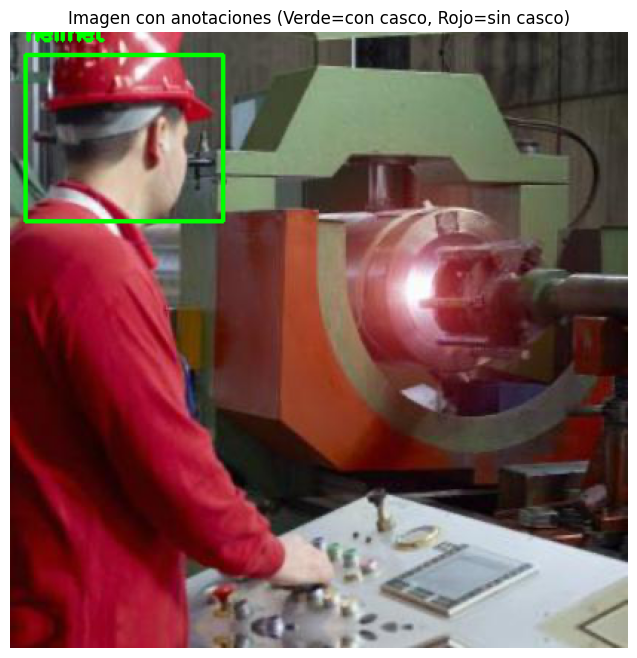

In [ ]:
# Visualizar una imagen con sus bounding boxes
img_name = os.listdir(images_dir)[0]
image = cv2.imread(os.path.join(images_dir, img_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

annotation_name = img_name.replace(".png", ".xml")
tree = ET.parse(os.path.join(annotations_dir, annotation_name))

image_with_boxes = image.copy()
for obj in tree.getroot().findall('object'):
    name = obj.find('name').text
    bndbox = obj.find('bndbox')
    xmin = int(bndbox.find('xmin').text)
    ymin = int(bndbox.find('ymin').text)
    xmax = int(bndbox.find('xmax').text)
    ymax = int(bndbox.find('ymax').text)

    # Verde = con casco, Rojo = sin casco
    if name in ['helmet', 'head with helmet', 'person with helmet']:
        color = (0, 255, 0)
    else:
        color = (255, 0, 0)

    cv2.rectangle(image_with_boxes, (xmin, ymin), (xmax, ymax), color, 2)
    cv2.putText(image_with_boxes, name, (xmin, ymin - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(10, 8))
plt.title("Imagen con anotaciones (Verde=con casco, Rojo=sin casco)")
plt.imshow(image_with_boxes)
plt.axis("off")
plt.show()

## 4. Preparación de los datos

### Proceso de preparación:
1. **Extracción de recortes:** Se parsean los XML y se recorta cada bounding box de la imagen original
2. **Mapeo de clases:** Se agrupan las 6 clases en 2 (con casco = 1, sin casco = 0)
3. **Redimensionamiento:** Cada recorte se redimensiona a 64x64 píxeles
4. **Normalización:** Valores de píxel de [0, 255] a [0, 1]
5. **Split:** 70% entrenamiento, 15% validación, 15% test
6. **Data Augmentation:** Flips y variaciones de brillo/contraste en el set de entrenamiento

In [ ]:
# Definir mapeo de clases a binario
# 1 = con casco, 0 = sin casco
CLASS_MAP = {
    'helmet': 1,
    'head with helmet': 1,
    'person with helmet': 1,
    'head': 0,
    'person without helmet': 0,
    'face': 0,
}

IMG_SIZE = 64
MIN_CROP_SIZE = 16  # Ignorar bounding boxes muy pequeñas
MAX_CROPS_PER_IMAGE = 10  # Limitar recortes por imagen para ahorrar RAM

In [ ]:
# Extraer recortes de las bounding boxes
crops = []
labels = []
skipped = 0

for xml_file in os.listdir(annotations_dir):
    xml_path = os.path.join(annotations_dir, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Obtener nombre de la imagen
    img_filename = root.find('filename').text
    img_path = os.path.join(images_dir, img_filename)

    if not os.path.exists(img_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    crops_this_image = 0
    for obj in root.findall('object'):
        if crops_this_image >= MAX_CROPS_PER_IMAGE:
            break

        name = obj.find('name').text
        if name not in CLASS_MAP:
            continue

        bndbox = obj.find('bndbox')
        xmin = max(0, int(bndbox.find('xmin').text))
        ymin = max(0, int(bndbox.find('ymin').text))
        xmax = min(w, int(bndbox.find('xmax').text))
        ymax = min(h, int(bndbox.find('ymax').text))

        # Filtrar bboxes demasiado pequeñas
        if (xmax - xmin) < MIN_CROP_SIZE or (ymax - ymin) < MIN_CROP_SIZE:
            skipped += 1
            continue

        crop = image[ymin:ymax, xmin:xmax]
        crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
        crop = crop / 255.0

        crops.append(crop)
        labels.append(CLASS_MAP[name])
        crops_this_image += 1

X = np.array(crops, dtype=np.float32)
y = np.array(labels, dtype=np.float32)

del crops, labels

print(f"Total de recortes extraídos: {len(X)}")
print(f"Recortes descartados (muy pequeños): {skipped}")
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"Distribución: Con casco={int(y.sum())}, Sin casco={int(len(y) - y.sum())}")
print(f"Proporción con casco: {y.mean():.3f}")
print(f"Memoria: X={X.nbytes/1e6:.0f} MB")

Total de recortes extraídos: 19187
Recortes descartados (muy pequeños): 3987
X shape: (19187, 64, 64, 3), dtype: float32
Distribución: Con casco=15070, Sin casco=4117
Proporción con casco: 0.785
Memoria: X=943 MB


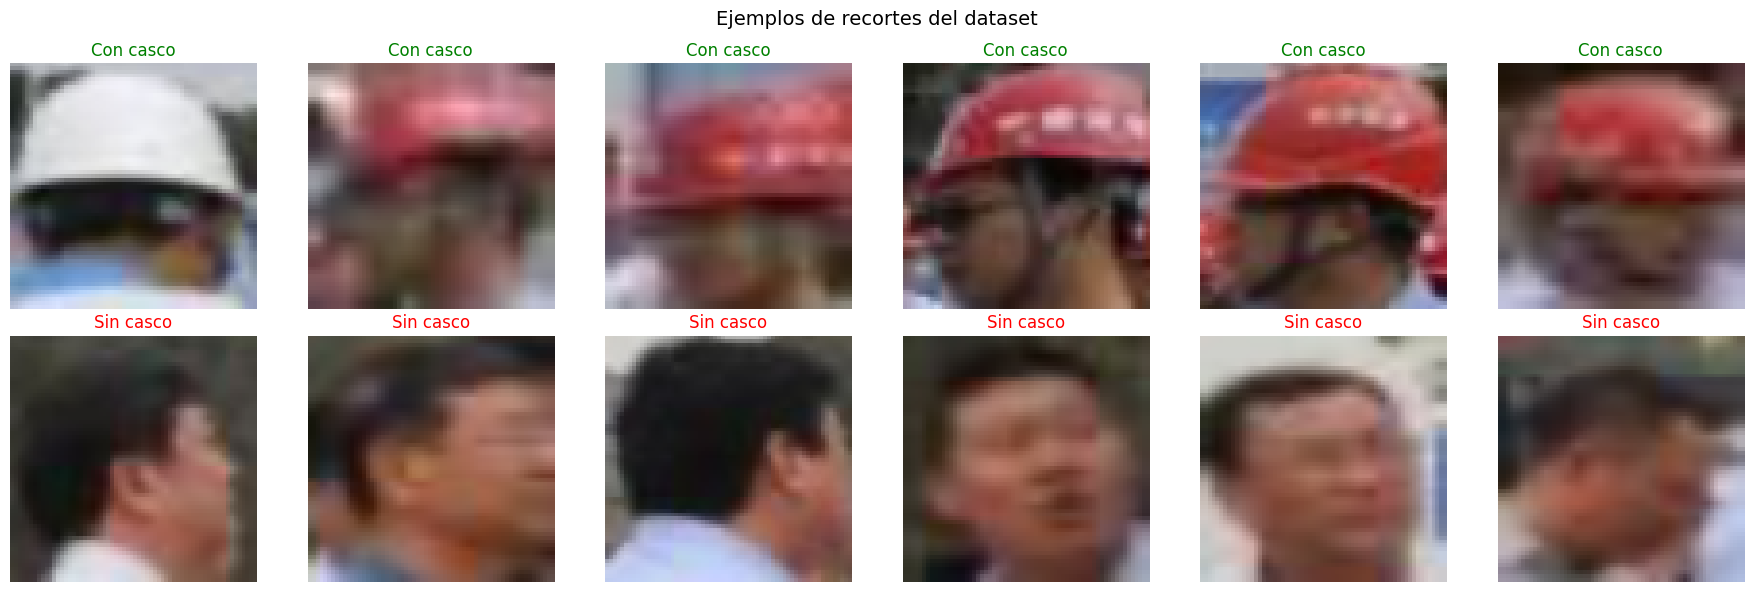

In [ ]:
# Visualizar ejemplos de recortes con sus etiquetas
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Mostrar 6 con casco y 6 sin casco
helmet_idx = np.where(y == 1)[0]
no_helmet_idx = np.where(y == 0)[0]

for i in range(6):
    axes[0, i].imshow(X[helmet_idx[i]])
    axes[0, i].set_title("Con casco", color='green')
    axes[0, i].axis('off')

    axes[1, i].imshow(X[no_helmet_idx[i]])
    axes[1, i].set_title("Sin casco", color='red')
    axes[1, i].axis('off')

plt.suptitle("Ejemplos de recortes del dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Split: 70% train, 15% val, 15% test
# Primero separamos test (15%), luego de lo restante separamos val
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Del 85% restante, 15/85 ≈ 0.176 para obtener 15% del total como validación
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

del X_temp, y_temp

print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%) - Con casco: {y_train.mean():.3f}")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%) - Con casco: {y_val.mean():.3f}")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%) - Con casco: {y_test.mean():.3f}")

Train: 13437 (70.0%) - Con casco: 0.785
Val:   2871 (15.0%) - Con casco: 0.785
Test:  2879 (15.0%) - Con casco: 0.785


In [ ]:
# Data augmentation y pipelines tf.data
BATCH_SIZE = 32

def augment(image, label):
    """Augmentation para el set de entrenamiento."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Pipeline de entrenamiento con augmentation
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(2000).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Pipeline de validación sin augmentation
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Pipeline de test sin augmentation
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Pipelines creados.")

Pipelines creados.


## 5. Arquitectura del modelo

Se utiliza una **CNN (Convolutional Neural Network)** diseñada para clasificación binaria, con la siguiente estructura:

- **4 bloques convolucionales** con filtros crecientes (32, 64, 128, 256), cada uno con Conv2D + BatchNorm + ReLU + MaxPooling
- **Dropout** (0.3 y 0.4) en los bloques más profundos para regularización
- **Global Average Pooling** para reducir los feature maps a un vector
- **Capa densa** de 128 neuronas con Dropout 0.5
- **Capa de salida** con 1 neurona y activación sigmoid (probabilidad de "con casco")

Se eligió Global Average Pooling en lugar de Flatten para reducir el número de parámetros y el riesgo de overfitting.

In [ ]:
def build_cnn(input_shape=(64, 64, 3)):

    inputs = layers.Input(input_shape)

    # Bloque 1: 32 filtros
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # Bloque 2: 64 filtros
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # Bloque 3: 128 filtros + Dropout
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Bloque 4: 256 filtros + Dropout
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Clasificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

In [ ]:
# model = build_cnn()
# model.summary()


# CAPAS CONVOLUCIONALES (La mayoría de los parámetros entrenables)
# Bloque 1: Conv2D (32 filtros)
# Filtros: 32 de tamaño 3×3

# Entrada: 3 canales (RGB)

# Fórmula: (altura_filtro × ancho_filtro × canales_entrada + 1 sesgo) × nº_filtros

# Cálculo: (3×3×3 + 1) × 32 = (27 + 1) × 32 = 28 × 32 = 896 parámetros ✓

# Bloque 2: Conv2D (64 filtros)
# Entrada: 32 canales (del bloque anterior)

# Cálculo: (3×3×32 + 1) × 64 = (288 + 1) × 64 = 289 × 64 = 18,496 parámetros ✓

# Bloque 3: Conv2D (128 filtros)
# Entrada: 64 canales

# Cálculo: (3×3×64 + 1) × 128 = (576 + 1) × 128 = 577 × 128 = 73,856 parámetros ✓

# Bloque 4: Conv2D (256 filtros)
# Entrada: 128 canales

# Cálculo: (3×3×128 + 1) × 256 = (1,152 + 1) × 256 = 1,153 × 256 = 295,168 parámetros ✓

# Subtotal convoluciones: 896 + 18,496 + 73,856 + 295,168 = 388,416 parámetros

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Métricas de evaluación

Para evaluar la solución se utilizan las siguientes métricas:

- **Accuracy:** Proporción de predicciones correctas sobre el total. Es útil pero puede ser engañosa con clases desbalanceadas.
- **Precision:** De todos los que el modelo predijo como "con casco", cuántos realmente tenían casco. Relevante para evitar falsos positivos (decir que alguien tiene casco cuando no lo tiene, lo cual es peligroso).
- **Recall (Sensibilidad):** De todos los que realmente no tenían casco, cuántos detectó correctamente. Crucial en seguridad laboral: no queremos que se nos escapen personas sin casco.
- **F1-Score:** Media armónica de Precision y Recall. Balancea ambas métricas.
- **AUC-ROC:** Área bajo la curva ROC. Mide la capacidad del modelo de distinguir entre clases independientemente del umbral de decisión. Un valor de 1.0 es perfecto, 0.5 es aleatorio.

## 7. Entrenamiento

In [ ]:
# Compilación del modelo
# Se usa Binary Cross-Entropy como loss (estándar para clasificación binaria)
# Adam con learning rate 1e-4 para convergencia estable

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

In [ ]:
# Callbacks para controlar el entrenamiento
# - ReduceLROnPlateau: reduce el learning rate si val_loss no mejora en 5 epochs
# - EarlyStopping: frena el entrenamiento si val_loss no mejora en 10 epochs
#   y restaura los mejores pesos
# - ModelCheckpoint: guarda el mejor modelo según val_auc

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_helmet_cnn.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# Entrenamiento
# Se entrena hasta 50 epochs con early stopping para evitar overfitting

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8529 - auc: 0.8722 - loss: 0.3360 - precision: 0.8958 - recall: 0.9223
Epoch 1: val_auc improved from -inf to 0.96739, saving model to best_helmet_cnn.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.8530 - auc: 0.8723 - loss: 0.3358 - precision: 0.8959 - recall: 0.9224 - val_accuracy: 0.8304 - val_auc: 0.9674 - val_loss: 0.3597 - val_precision: 0.9862 - val_recall: 0.7951 - learning_rate: 1.0000e-04
Epoch 2/50
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9354 - auc: 0.9722 - loss: 0.1680 - precision: 0.9585 - recall: 0.9600
Epoch 2: val_auc improved from 0.96739 to 0.98849, saving model to best_helmet_cnn.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9354 - auc: 0.9722 - loss: 0.1679 - precision: 0.9585 - recall: 0.9600 - val_accuracy: 0.9561 - val_auc: 0.9885 - val_loss: 0.1093 - val_precision: 0.9716 - val_recall: 0.9725 - learning_rate: 1.0000e-04
Epoch 3/50
417/420 ━━━━━━━━━

## 8. Resultados y discusión

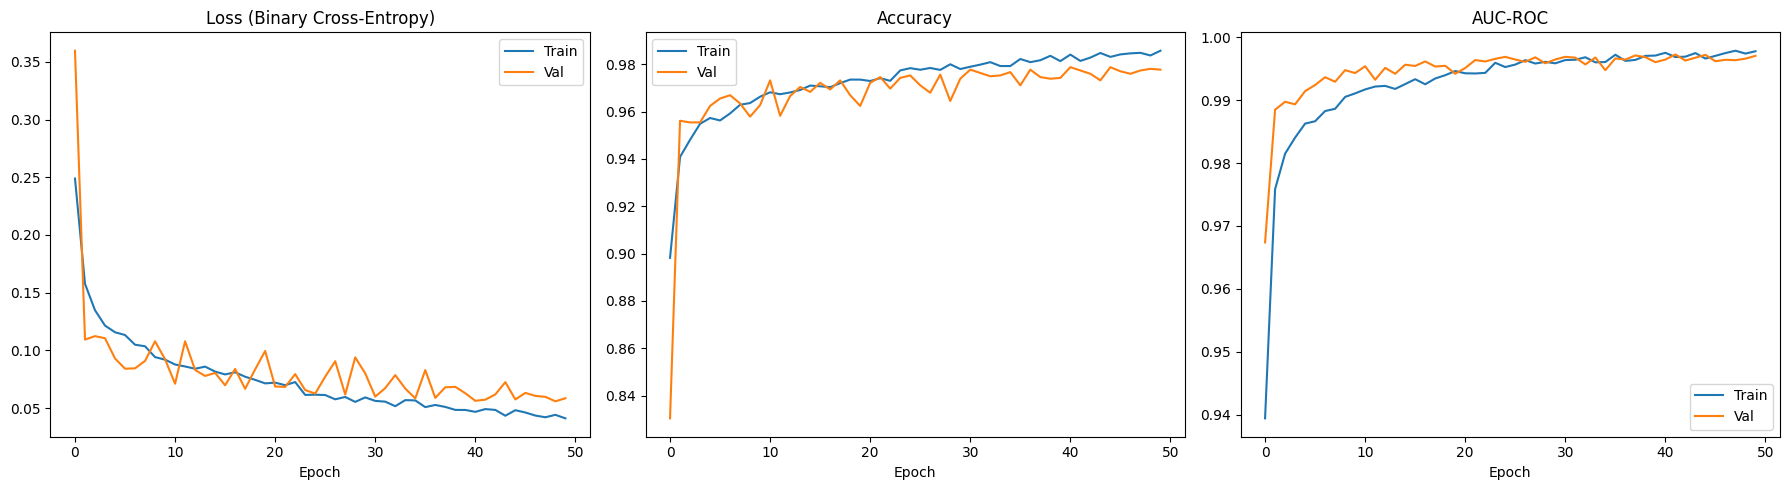

In [ ]:
# Curvas de entrenamiento
# Estas gráficas permiten analizar si hubo overfitting:
# - Si las curvas de train y val divergen mucho, hay overfitting
# - Si ambas bajan/suben juntas, el modelo generaliza bien

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss (Binary Cross-Entropy)')
axes[0].legend()
axes[0].set_xlabel('Epoch')

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].set_xlabel('Epoch')

# AUC
axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Val')
axes[2].set_title('AUC-ROC')
axes[2].legend()
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

### Análisis de overfitting

Las curvas de entrenamiento muestran que el modelo generaliza correctamente: la accuracy de validación se mantiene cercana a la de entrenamiento (~97.7% vs ~98.5%) y no se observa una divergencia significativa entre ambas curvas. La val_loss se estabiliza alrededor de 0.06 mientras que la train_loss baja hasta ~0.04.

El learning rate fue reducido automáticamente dos veces por el callback ReduceLROnPlateau (de 1e-4 a 5e-5 en epoch 24, a 2.5e-5 en epoch 41, y a 1.25e-5 en epoch 47), lo que permitió al modelo seguir mejorando sin oscilaciones. El early stopping no se activó, ya que el modelo siguió mejorando marginalmente hasta la epoch 50.

Las estrategias utilizadas para prevenir el overfitting fueron:
- **Dropout** progresivo (0.3, 0.4, 0.5) en las capas más profundas
- **BatchNormalization** en cada bloque convolucional
- **Data augmentation** (flips horizontales, variaciones de brillo y contraste)
- **Early stopping** configurado para detener si val_loss no mejora en 10 epochs
- **ReduceLROnPlateau** que redujo el learning rate progresivamente
- **Global Average Pooling** en vez de Flatten, reduciendo la cantidad de parámetros

In [ ]:
# Evaluación final en el set de TEST (datos nunca vistos durante entrenamiento)
test_results = model.evaluate(test_ds)
print(f"\n--- Resultados en Test Set ---")
print(f"Loss:      {test_results[0]:.4f}")
print(f"Accuracy:  {test_results[1]:.4f}")
print(f"Precision: {test_results[2]:.4f}")
print(f"Recall:    {test_results[3]:.4f}")
print(f"AUC-ROC:   {test_results[4]:.4f}")

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9781 - auc: 0.9939 - loss: 0.0697 - precision: 0.9917 - recall: 0.9801

--- Resultados en Test Set ---
Loss:      0.0639
Accuracy:  0.9795
Precision: 0.9902
Recall:    0.9836
AUC-ROC:   0.9943


In [ ]:
# Predicciones en test para análisis detallado
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification Report (Precision, Recall, F1 por clase)
print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Sin casco', 'Con casco']))

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Classification Report:
              precision    recall  f1-score   support

   Sin casco       0.94      0.96      0.95       618
   Con casco       0.99      0.98      0.99      2261

    accuracy                           0.98      2879
   macro avg       0.97      0.97      0.97      2879
weighted avg       0.98      0.98      0.98      2879



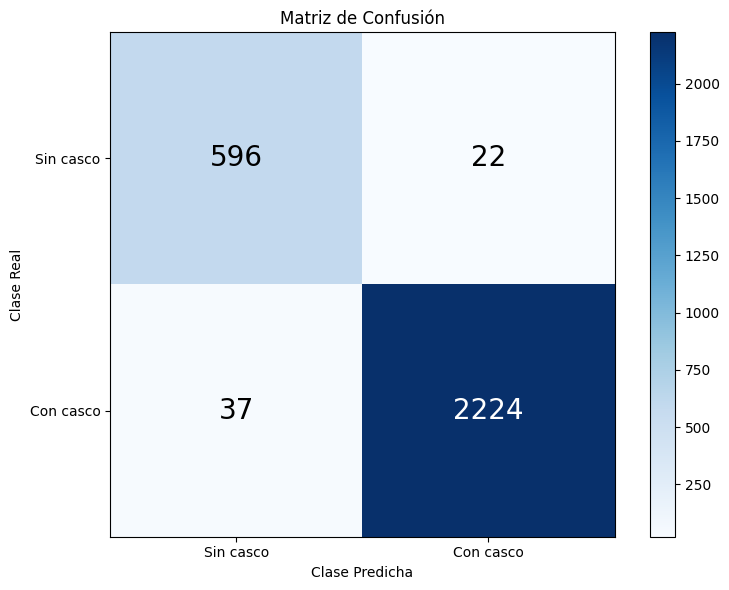

In [ ]:
# Matriz de confusión
# Muestra los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos
# En seguridad laboral, los falsos negativos (predecir "con casco" cuando no lo tiene)
# son los más peligrosos

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

classes = ['Sin casco', 'Con casco']
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=classes, yticklabels=classes,
       title='Matriz de Confusión',
       ylabel='Clase Real',
       xlabel='Clase Predicha')

# Agregar números en cada celda
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=20)

plt.tight_layout()
plt.show()

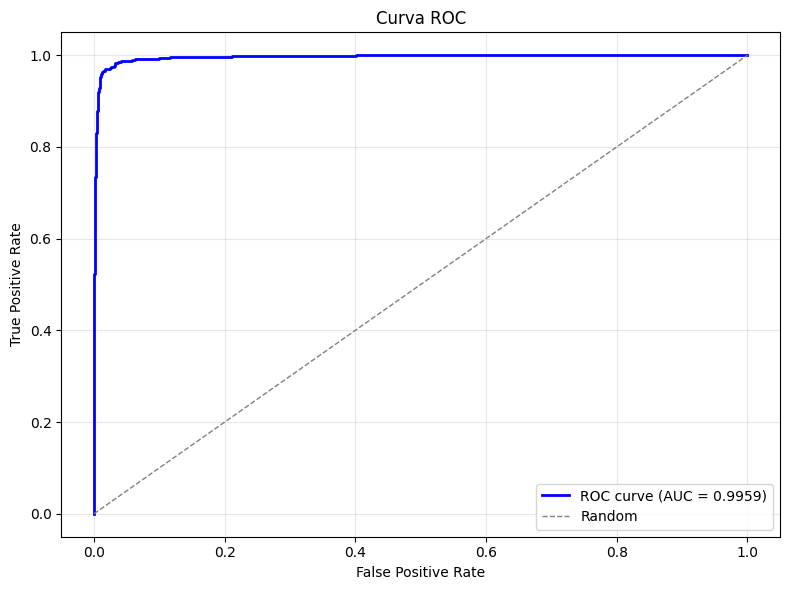

In [ ]:
# Curva ROC
# Muestra el trade-off entre True Positive Rate y False Positive Rate
# a distintos umbrales de decisión

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

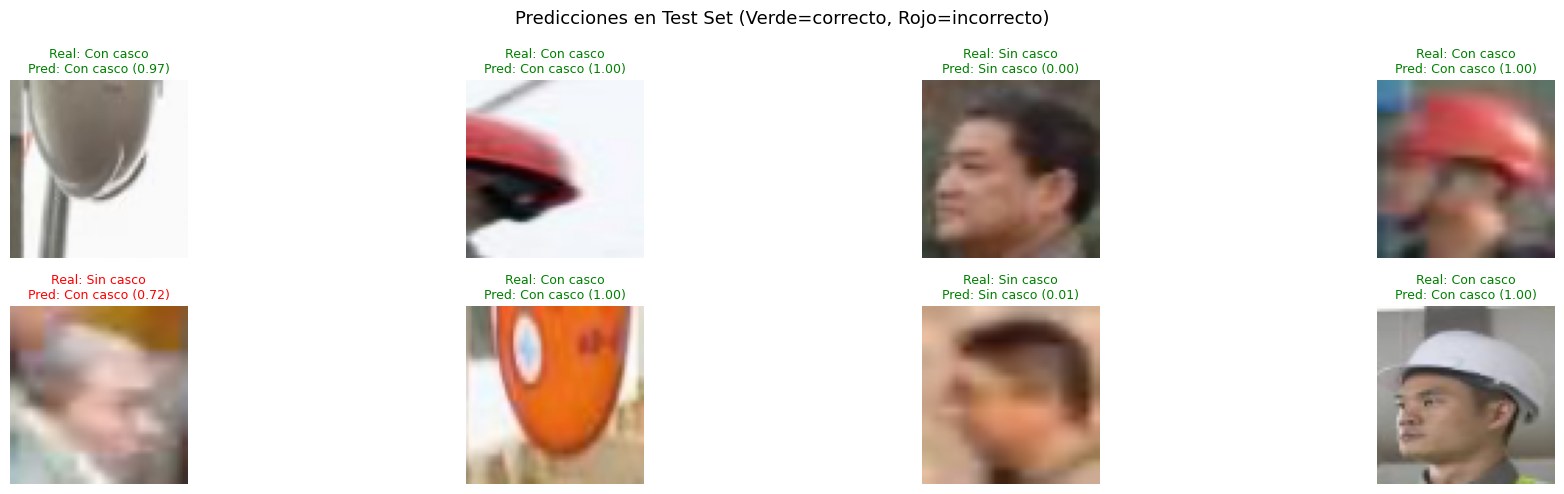

In [ ]:
# Visualizar predicciones en ejemplos del test set
n_examples = 8
random_idx = np.random.choice(len(X_test), n_examples, replace=False)

plt.figure(figsize=(20, 5))
for i, idx in enumerate(random_idx):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[idx])

    true_label = 'Con casco' if y_test[idx] == 1 else 'Sin casco'
    pred_label = 'Con casco' if y_pred[idx] == 1 else 'Sin casco'
    prob = y_pred_prob[idx][0]

    correct = y_test[idx] == y_pred[idx]
    color = 'green' if correct else 'red'

    plt.title(f"Real: {true_label}\nPred: {pred_label} ({prob:.2f})",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Predicciones en Test Set (Verde=correcto, Rojo=incorrecto)", fontsize=13)
plt.tight_layout()
plt.show()

### Discusión de resultados

El modelo alcanzó en el set de test una **accuracy del 97.95%**, **precision del 99.02%**, **recall del 98.36%** y un **AUC-ROC de 0.9943**. Estos resultados son notablemente altos, lo cual se explica por la naturaleza de la tarea: los recortes ya están aislados por las bounding boxes, y la diferencia visual entre una cabeza con casco y una sin casco es muy marcada (forma, color, textura del casco).

**Reflexión sobre las métricas:**
- La **accuracy** (97.95%) confirma que el modelo clasifica correctamente la gran mayoría de los recortes. Sin embargo, dado que las clases están desbalanceadas (2261 con casco vs 618 sin casco en test), esta métrica por sí sola no es suficiente.
- El **recall de la clase 'sin casco'** es 0.96, lo que significa que el modelo detecta correctamente el 96% de las personas sin protección. El 4% restante que no detecta representan **falsos negativos**, que en un contexto de seguridad laboral son el error más peligroso: personas sin casco que el sistema no alerta.
- La **precision de 'sin casco'** es 0.94, lo que indica que cuando el modelo alerta que alguien no tiene casco, acierta el 94% de las veces.
- El **AUC-ROC de 0.9943** (muy cercano a 1.0) indica que el modelo tiene excelente capacidad de discriminación entre ambas clases independientemente del umbral de decisión.

**Principales dificultades y limitaciones:**
- Las bounding boxes varían mucho en tamaño; recortes muy pequeños pierden información al redimensionarse a 64x64.
- Se limitaron los recortes a 10 por imagen para poder entrenar en Google Colab con RAM limitada, lo que reduce la cantidad total de datos de entrenamiento.
- El modelo clasifica recortes individuales y no integra detección de objetos: no localiza personas en la imagen completa. Para un sistema en producción, se necesitaría combinar esta CNN con un detector de objetos (como YOLO o Faster R-CNN) que primero localice a las personas y luego clasifique cada una.

## 9. Conclusiones

Se implementó una CNN de clasificación binaria para detectar el uso de cascos de seguridad en imágenes de entornos de construcción, utilizando el dataset SHEL5K de 5.000 imágenes con más de 75.000 instancias anotadas. Las 6 clases originales se agruparon en dos categorías: con casco y sin casco.

El preprocesamiento incluyó la extracción de recortes a partir de las bounding boxes anotadas en formato XML, el redimensionamiento a 64x64 píxeles y la normalización al rango [0, 1]. Se aplicó data augmentation (flips horizontales y variaciones de brillo/contraste) y se dividieron los datos en 70% entrenamiento, 15% validación y 15% test con estratificación para mantener la proporción de clases.

La arquitectura consiste en 4 bloques convolucionales con filtros crecientes (32, 64, 128, 256), BatchNormalization, Dropout progresivo (0.3 a 0.5) y Global Average Pooling, totalizando un modelo compacto y regularizado. Se entrenó con Binary Cross-Entropy, optimizador Adam (lr=1e-4) y callbacks de EarlyStopping, ReduceLROnPlateau y ModelCheckpoint.

El modelo alcanzó en el set de test un accuracy del 97.95%, precision del 99.02%, recall del 98.36% y AUC-ROC de 0.9943. El F1-score fue de 0.95 para la clase 'sin casco' y 0.99 para 'con casco'. Las curvas de entrenamiento mostraron convergencia estable. La principal limitación del recall de 'sin casco' (0.96) es que un 4% de personas sin protección no serían detectadas, lo cual en un contexto de seguridad laboral requiere atención.

Estos resultados demuestran que una CNN relativamente simple es altamente efectiva para clasificar recortes de personas con y sin casco. Como trabajo futuro, la integración con un detector de objetos (como YOLO) permitiría un sistema end-to-end que localice y clasifique personas automáticamente a partir de imágenes completas de cámaras de vigilancia en obras de construcción.